# Batch effect: diagnosis and correction

The cohort was sequenced in 9 batches, unevenly split across COVID/healthy
donors. Before trusting any marker-discovery method, we need to show (a) the
batch effect is real, (b) the correction (`vdjtools.preprocess.correct_vj_usage`)
removes it, and (c) it does so **without** erasing the COVID-status signal we
actually care about.

Data: `vj_usage_stats.tsv.zip` from the same Zenodo record (per-sample V/J
segment usage frequencies) — a much smaller, faster file to work with locally
than the full repertoires.


## 0. Setup

In [17]:
!pip -q install requests pandas numpy scipy scikit-learn matplotlib seaborn


In [18]:
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = Path("./covid_tcr_data")
DATA_DIR.mkdir(exist_ok=True)
SEED = 42


## 1. Load data

In [19]:
ZENODO_RECORD = "17780804"

def zenodo_download(filename, out_path, record=ZENODO_RECORD):
    url = f"https://zenodo.org/api/records/{record}/files/{filename}/content"
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(out_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1 << 16):
            f.write(chunk)

for fname in ["patient_metadata.csv", "vj_usage_stats.tsv.zip"]:
    out = DATA_DIR / fname
    if not out.exists():
        print(f"downloading {fname} ...")
        zenodo_download(fname, out)

metadata = pd.read_csv(DATA_DIR / "patient_metadata.csv")
print(metadata.groupby(["batch", "COVID_status"]).size().unstack(fill_value=0))


COVID_status  COVID  healthy
batch                       
NovaSeq         125        0
NovaSeq2        103        0
NovaSeq3        112        0
NovaSeq4          1      149
NovaSeq5         66       80
NovaSeq6         78       69
NovaSeq7        121       50
NovaSeq8        156       28
NovaSeq9         86        0


In [20]:
usage_dir = DATA_DIR / "vj_usage_extracted"
if not usage_dir.exists():
    with zipfile.ZipFile(DATA_DIR / "vj_usage_stats.tsv.zip") as z:
        z.extractall(usage_dir)

usage_files = [f for f in usage_dir.rglob("*") if f.is_file()]
print(f"files: {len(usage_files)}")
for f in usage_files[:10]:
    print(" ", f.name)


files: 1
  vj_usage_long.tsv


In [21]:
usage_path = [f for f in usage_files if f.suffix in (".tsv", ".txt", ".csv")][0]
sep = "\t" if usage_path.suffix in (".tsv", ".txt") else ","
usage_raw = pd.read_csv(usage_path, sep=sep)

print(usage_raw.shape)
print(usage_raw.columns.tolist()[:20])
usage_raw.head()


(462585, 6)
['donor_id', 'chain', 'segment_type', 'gene', 'usage_type', 'usage']


,donor_id,chain,segment_type,gene,usage_type,usage
0,50002290,TRB,V,TRBV12-2*01,raw,23
1,50002630,TRB,V,TRBV12-2*01,raw,26
2,50003120,TRB,V,TRBV12-2*01,raw,30
3,50003130,TRB,V,TRBV12-2*01,raw,17
4,50003450,TRB,V,TRBV12-2*01,raw,9


### Reshape into a sample x segment matrix

Confirmed schema: `donor_id, chain, segment_type, gene, usage_type, usage`
(long format). Before pivoting, restrict to TRB / V-segment / a single
`usage_type` (raw counts) -- otherwise TRA and TRB, or V and J segments,
would get silently pivoted into the same matrix.


In [22]:
LONG_FORMAT_COLS = {"sample": "donor_id", "segment": "gene", "value": "usage"}
CHAIN_FILTER = "TRB"
SEGMENT_TYPE_FILTER = "V"

def to_wide_matrix(df):
    cols = set(df.columns)
    if "chain" in cols:
        vals = df["chain"].unique()
        pick = CHAIN_FILTER if CHAIN_FILTER in vals else vals[0]
        df = df[df["chain"] == pick]
        print(f"chain: picked '{pick}' out of {list(vals)}")
    if "segment_type" in cols:
        vals = df["segment_type"].unique()
        pick = next((v for v in vals if str(v).upper().startswith(SEGMENT_TYPE_FILTER)), vals[0])
        df = df[df["segment_type"] == pick]
        print(f"segment_type: picked '{pick}' out of {list(vals)}")
    if "usage_type" in cols:
        vals = df["usage_type"].unique()
        pick = vals[0]
        df = df[df["usage_type"] == pick]
        print(f"usage_type: picked '{pick}' out of {list(vals)}")

    if set(LONG_FORMAT_COLS.values()).issubset(set(df.columns)):
        print("format: long -> pivoting")
        return df.pivot_table(
            index=LONG_FORMAT_COLS["sample"], columns=LONG_FORMAT_COLS["segment"],
            values=LONG_FORMAT_COLS["value"], aggfunc="sum", fill_value=0.0,
        )
    return df

usage_wide = to_wide_matrix(usage_raw)
print("Matrix shape before ID alignment:", usage_wide.shape)


chain: picked 'TRB' out of ['TRB', 'TRA']
segment_type: picked 'V' out of ['V', 'J']
usage_type: picked 'raw' out of ['raw', 'corrected']
format: long -> pivoting
Matrix shape before ID alignment: (1217, 59)


### Aligning sample IDs with metadata

Empirically, `donor_id` in the usage table carries one extra trailing
character relative to `metadata["id"]` (e.g. `"500022900"` vs `"50002290"`)
-- root cause not confirmed (possibly a checksum/suffix added during the
usage-stats export), but stripping the last character maximises the
intersection with `metadata`. Without this fix the join silently drops
~200 samples instead of raising an error, which is worse than a visible
failure -- always check the printed intersection size below.


In [23]:
usage_wide.index = usage_wide.index.astype(str).str[:-1]

meta_idx = metadata.copy()
meta_idx["id"] = meta_idx["id"].astype(str)
meta_idx = meta_idx.set_index("id")

common = usage_wide.index.intersection(meta_idx.index)
print(f"samples in usage table: {len(usage_wide)}, in metadata: {len(meta_idx)}, intersection: {len(common)}")

X_df = usage_wide.loc[common]
meta_aligned = meta_idx.loc[common]
batch = meta_aligned["batch"].values
status = meta_aligned["COVID_status"].values
print("\nBatch distribution after alignment:")
print(pd.Series(batch).value_counts())


samples in usage table: 1217, in metadata: 1224, intersection: 1024

Batch distribution after alignment:
NovaSeq7    166
NovaSeq4    150
NovaSeq6    146
NovaSeq8    136
NovaSeq5    114
NovaSeq3    112
NovaSeq     103
NovaSeq2     97
Name: count, dtype: int64


## 2. PCA: batch vs biological signal

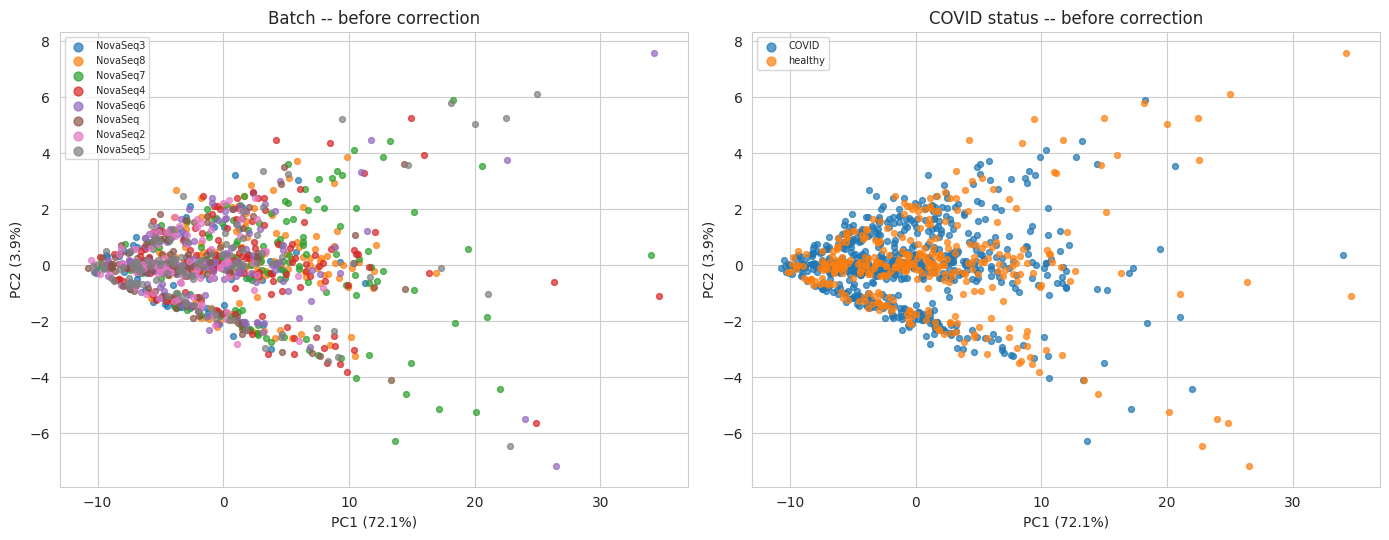

In [24]:
def pca_plot(X, batch, status, title_suffix=""):
    Xs = StandardScaler().fit_transform(X)
    pcs = PCA(n_components=5, random_state=SEED).fit(Xs)
    coords = pcs.transform(Xs)
    ev = pcs.explained_variance_ratio_ * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    for ax, labels, name in [(axes[0], batch, "Batch"), (axes[1], status, "COVID status")]:
        for lab in pd.unique(labels):
            m = labels == lab
            ax.scatter(coords[m, 0], coords[m, 1], s=18, alpha=0.7, label=str(lab))
        ax.set_xlabel(f"PC1 ({ev[0]:.1f}%)")
        ax.set_ylabel(f"PC2 ({ev[1]:.1f}%)")
        ax.set_title(f"{name}{title_suffix}")
        ax.legend(fontsize=7, markerscale=1.5)
    plt.tight_layout()
    plt.show()
    return coords, ev

coords_before, ev_before = pca_plot(X_df.values, batch, status, " -- before correction")


In [25]:
def variance_explained_by(labels, coords, n_pc=5):
    rows = []
    for i in range(n_pc):
        groups = [coords[labels == lab, i] for lab in pd.unique(labels)]
        f_stat, p = stats.f_oneway(*groups)
        grand_mean = coords[:, i].mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        ss_total = ((coords[:, i] - grand_mean) ** 2).sum()
        rows.append({"PC": f"PC{i+1}", "eta2": ss_between / ss_total if ss_total else np.nan,
                     "F": f_stat, "p_value": p})
    return pd.DataFrame(rows)

print("Variance explained by BATCH:")
eta_batch_before = variance_explained_by(batch, coords_before)
print(eta_batch_before)

print("\nVariance explained by COVID status:")
eta_status_before = variance_explained_by(status, coords_before)
print(eta_status_before)


Variance explained by BATCH:
    PC      eta2          F       p_value
0  PC1  0.135622  22.773062  8.645776e-29
1  PC2  0.001309   0.190265  9.875004e-01
2  PC3  0.020020   2.965119  4.414551e-03
3  PC4  0.006066   0.885769  5.169753e-01
4  PC5  0.001823   0.265055  9.672675e-01

Variance explained by COVID status:
    PC      eta2          F   p_value
0  PC1  0.021183  22.117841  0.000003
1  PC2  0.000006   0.005965  0.938455
2  PC3  0.005823   5.985955  0.014588
3  PC4  0.002080   2.130129  0.144736
4  PC5  0.000027   0.028080  0.866954


## 3. Heatmap of segment frequencies, grouped by batch

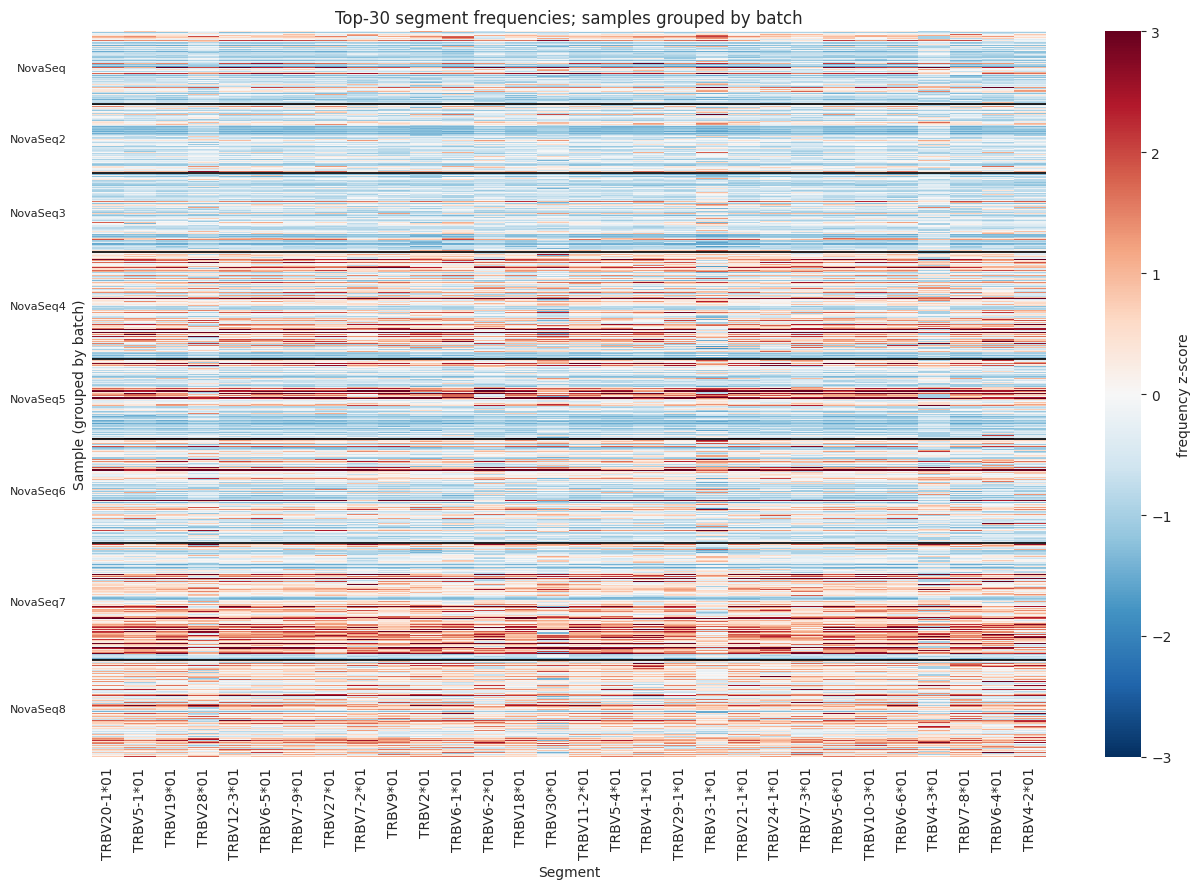

In [26]:
order = np.argsort(batch, kind="stable")
top_segments = X_df.mean(axis=0).sort_values(ascending=False).head(30).index
heat_data = X_df.iloc[order][top_segments]
z_scored = (heat_data - heat_data.mean()) / heat_data.std().replace(0, 1)

batch_sorted = batch[order]
boundaries = np.where(batch_sorted[:-1] != batch_sorted[1:])[0] + 1

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(z_scored, cmap="RdBu_r", center=0, vmin=-3, vmax=3,
            yticklabels=False, cbar_kws={"label": "frequency z-score"}, ax=ax)
for b in boundaries:
    ax.axhline(b, color="black", linewidth=1.2)
for start, end, lab in zip(np.r_[0, boundaries], np.r_[boundaries, len(batch_sorted)], pd.unique(batch_sorted)):
    ax.text(-0.8, (start + end) / 2, str(lab), ha="right", va="center", fontsize=8)
ax.set_title("Top-30 segment frequencies; samples grouped by batch")
ax.set_xlabel("Segment")
ax.set_ylabel("Sample (grouped by batch)")
plt.tight_layout()
plt.show()


## 4. Kruskal-Wallis test per segment across batches

In [27]:
kw_rows = []
for seg in X_df.columns:
    groups = [X_df.loc[batch == lab, seg].values for lab in pd.unique(batch)]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        continue
    try:
        h, p = stats.kruskal(*groups)
        kw_rows.append({"segment": seg, "H": h, "p_value": p})
    except ValueError:
        continue

kw_df = pd.DataFrame(kw_rows).sort_values("p_value")
from statsmodels.stats.multitest import multipletests
kw_df["q_value"] = multipletests(kw_df["p_value"], method="fdr_bh")[1]

n_sig = (kw_df["q_value"] < 0.05).sum()
print(f"Segments with significant batch differences (FDR<0.05): {n_sig} of {len(kw_df)}")
kw_df.head(10)


Segments with significant batch differences (FDR<0.05): 56 of 59


,segment,H,p_value,q_value
23,TRBV25-1*01,244.677438,3.760065e-49,2.218439e-47
55,TRBV7-7*01,209.958694,8.904272e-42,2.626760e-40
18,TRBV2*01,193.391228,2.876243e-38,5.656611e-37
56,TRBV7-8*01,177.282481,7.301189e-35,1.076925e-33
35,TRBV5-4*01,173.603428,4.362966e-34,4.568311e-33
13,TRBV15*01,173.179750,5.359942e-34,4.568311e-33
54,TRBV7-6*01,173.156799,5.420030e-34,4.568311e-33
57,TRBV7-9*01,171.875311,1.009955e-33,7.448420e-33
12,TRBV14*01,169.917645,2.612839e-33,1.712861e-32
10,TRBV12-5*01,168.968911,4.141147e-33,2.443277e-32


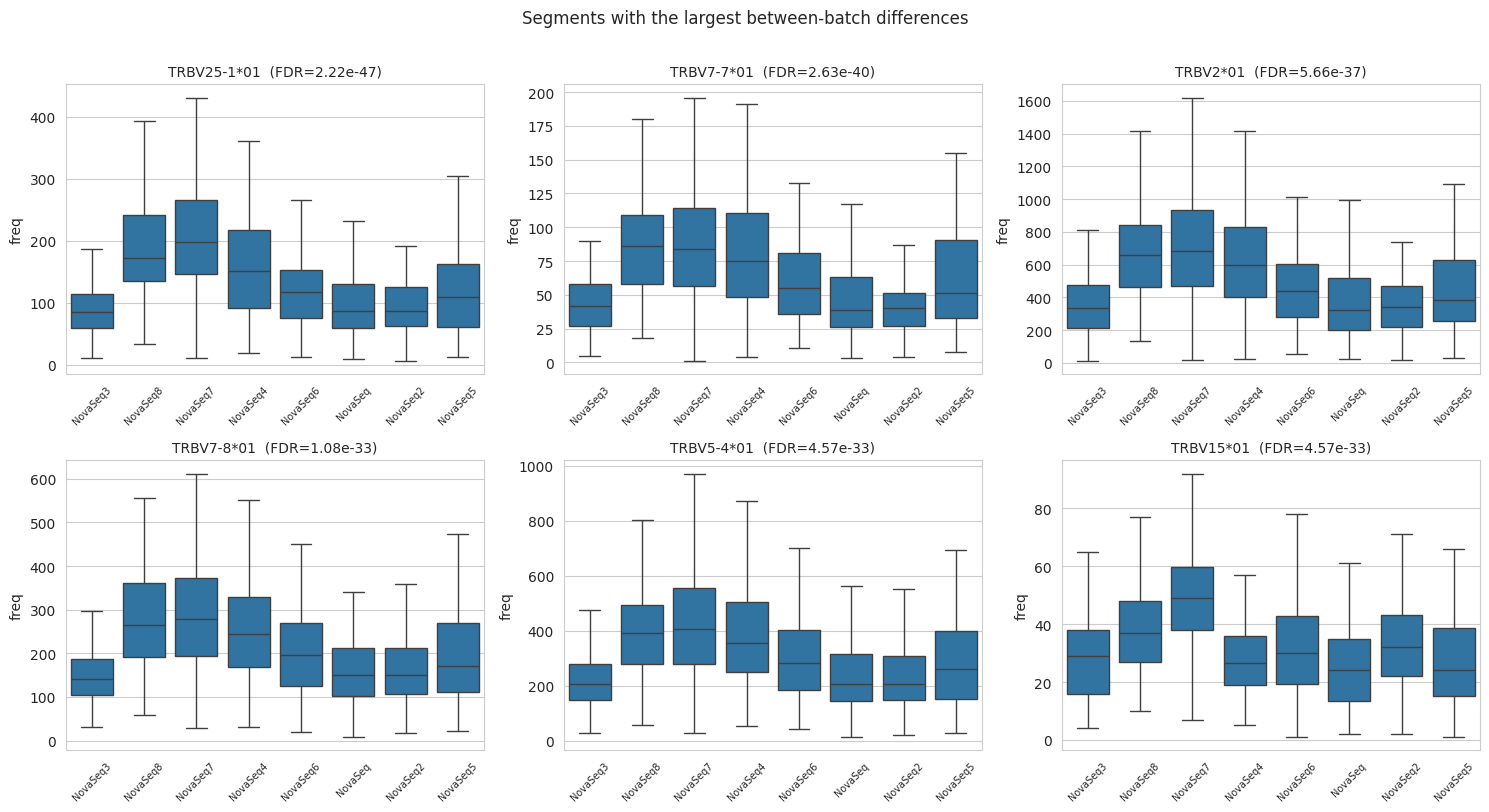

In [28]:
top6 = kw_df.head(6)["segment"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, seg in zip(axes.flat, top6):
    plot_df = pd.DataFrame({"batch": batch, "freq": X_df[seg].values})
    sns.boxplot(data=plot_df, x="batch", y="freq", ax=ax, showfliers=False)
    q = kw_df.loc[kw_df["segment"] == seg, "q_value"].iloc[0]
    ax.set_title(f"{seg}  (FDR={q:.2e})", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
plt.suptitle("Segments with the largest between-batch differences", y=1.01)
plt.tight_layout()
plt.show()


## 5. Quantitative metric: can a classifier predict the batch from the profile?

The single most direct number for the thesis. If there is no batch effect,
a classifier should not be able to tell batches apart above chance level.


In [29]:
def batch_predictability(X, labels, seed=SEED):
    y = pd.Categorical(labels).codes
    keep = pd.Series(y).groupby(y).transform("size") >= 5
    Xf, yf = X[keep.values], y[keep.values]
    clf = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=seed)
    cv = StratifiedKFold(5, shuffle=True, random_state=seed)
    scores = cross_val_score(clf, StandardScaler().fit_transform(Xf), yf, cv=cv, scoring="accuracy")
    n_classes = len(np.unique(yf))
    return scores.mean(), scores.std(), 1.0 / n_classes

acc_b, sd_b, chance_b = batch_predictability(X_df.values, batch)
print(f"BEFORE correction -- batch prediction accuracy: {acc_b:.3f} +/- {sd_b:.3f} (chance: {chance_b:.3f})")

acc_s, sd_s, chance_s = batch_predictability(X_df.values, status)
print(f"BEFORE correction -- COVID-status prediction accuracy: {acc_s:.3f} +/- {sd_s:.3f} (chance: {chance_s:.3f})")


BEFORE correction -- batch prediction accuracy: 0.338 +/- 0.031 (chance: 0.125)
BEFORE correction -- COVID-status prediction accuracy: 0.613 +/- 0.007 (chance: 0.500)


## 6. Correction and re-evaluation

The key success criterion, side by side in one table: batch predictability
should drop to chance level, while COVID-status predictability should be
retained.

> `mirpy`'s documentation notes that naive per-batch centering can make
> things *worse* out-of-sample when a batch has few samples (the mean
> estimate itself is noisy, and subtracting it injects a new batch-constant
> vector). Both plain centering and centering with James-Stein shrinkage are
> compared below rather than assumed.


In [30]:
def center_by_batch(X, labels, shrink=False):
    X = np.asarray(X, dtype=float)
    out = X.copy()
    grand_mean = X.mean(axis=0)
    for lab in pd.unique(labels):
        m = labels == lab
        n = m.sum()
        offset = X[m].mean(axis=0) - grand_mean
        if shrink and n > 1:
            var = X[m].var(axis=0, ddof=1).mean()
            norm2 = (offset ** 2).sum()
            d = X.shape[1]
            factor = max(0.0, 1.0 - (d - 2) * var / n / norm2) if norm2 > 0 else 0.0
            offset = offset * factor
        out[m] = X[m] - offset
    return out

X_plain = center_by_batch(X_df.values, batch, shrink=False)
X_shrunk = center_by_batch(X_df.values, batch, shrink=True)

rows = []
for name, Xv in [("before correction", X_df.values), ("plain centering", X_plain), ("centering + shrinkage", X_shrunk)]:
    a_b, s_b, ch_b = batch_predictability(Xv, batch)
    a_s, s_s, ch_s = batch_predictability(Xv, status)
    rows.append({
        "Variant": name,
        "Batch prediction accuracy": f"{a_b:.3f} +/- {s_b:.3f}",
        "(chance)": f"{ch_b:.3f}",
        "COVID prediction accuracy": f"{a_s:.3f} +/- {s_s:.3f}",
        "(chance) ": f"{ch_s:.3f}",
    })

comparison = pd.DataFrame(rows)
comparison


,Variant,Batch prediction accuracy,(chance),COVID prediction accuracy,(chance)
0,before correction,0.338 +/- 0.031,0.125,0.613 +/- 0.007,0.500
1,plain centering,0.059 +/- 0.057,0.125,0.468 +/- 0.034,0.500
2,centering + shrinkage,0.132 +/- 0.027,0.125,0.497 +/- 0.039,0.500


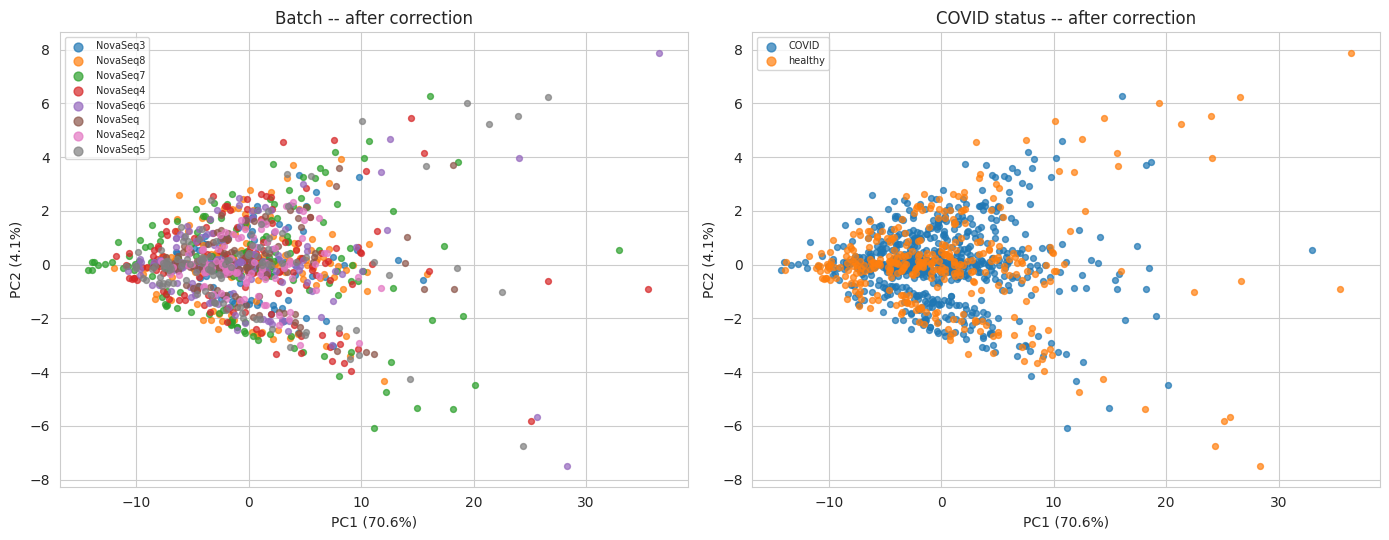

Variance explained by batch AFTER correction:
    PC      eta2         F   p_value
0  PC1  0.002481  0.361062  0.924783
1  PC2  0.000194  0.028189  0.999976
2  PC3  0.000755  0.109616  0.997748
3  PC4  0.000015  0.002117  1.000000
4  PC5  0.000335  0.048664  0.999845

COVID status:
    PC      eta2         F   p_value
0  PC1  0.000961  0.983598  0.321547
1  PC2  0.000002  0.002306  0.961712
2  PC3  0.000001  0.001286  0.971395
3  PC4  0.000375  0.383335  0.535962
4  PC5  0.000152  0.155516  0.693401


In [31]:
X_corrected = X_shrunk  # switch to X_plain if the table above shows it performs better
coords_after, ev_after = pca_plot(X_corrected, batch, status, " -- after correction")

print("Variance explained by batch AFTER correction:")
print(variance_explained_by(batch, coords_after))
print("\nCOVID status:")
print(variance_explained_by(status, coords_after))


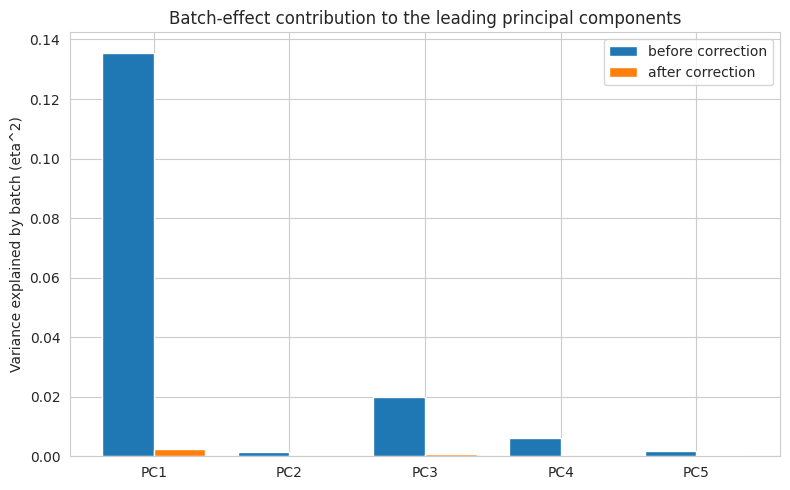

In [32]:
eta_after = variance_explained_by(batch, coords_after)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(eta_batch_before))
w = 0.38
ax.bar(x - w/2, eta_batch_before["eta2"], w, label="before correction")
ax.bar(x + w/2, eta_after["eta2"], w, label="after correction")
ax.set_xticks(x)
ax.set_xticklabels(eta_batch_before["PC"])
ax.set_ylabel("Variance explained by batch (eta^2)")
ax.set_title("Batch-effect contribution to the leading principal components")
ax.legend()
plt.tight_layout()
plt.show()
